# Option B — Kaggle API (for advanced)

In [1]:
!pip install kaggle pandas matplotlib seaborn --quiet
import os

# Ensure Kaggle directory exists
kaggle_dir = os.path.expanduser("~/.kaggle")
if not os.path.exists(kaggle_dir):
 os.makedirs(kaggle_dir)

# Download and unzip the dataset
!kaggle datasets download -d kunalgp/top-1000-most-played-spotify-songs-of-all-time -p ./spotify_dataset --unzip

# Confirm download
print("Files in directory:", os.listdir("./spotify_dataset"))


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset URL: https://www.kaggle.com/datasets/kunalgp/top-1000-most-played-spotify-songs-of-all-time
License(s): CC0-1.0

Files in directory: ['spotify_top_1000_tracks.csv']



  0%|          | 0.00/52.0k [00:00<?, ?B/s]
100%|██████████| 52.0k/52.0k [00:00<00:00, 329kB/s]
100%|██████████| 52.0k/52.0k [00:00<00:00, 326kB/s]


# Load and Preprocess the Dataset

In [16]:
import pandas as pd 
import os 

# Define the dataset path using your absolute file path 
dataset_path = "spotify_top_1000_tracks.csv"

# Load dataset 
df = pd.read_csv(dataset_path, encoding="utf-8") 

# Convert release_date and extract year 
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce') 
df['year'] = df['release_date'].dt.year 

# FIX: We REMOVE the line that tried to create 'duration_min'  
# because it already exists in the CSV file you loaded. 
# (The 'duration_min' column is ready for use!) 

print("Dataset loaded and basic preprocessing complete!") 
print(df.head(3))

Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


# Data Cleaning and Feature Engineering

In [17]:
import numpy as np 

# Clean up text columns 
df['track_name'] = df['track_name'].str.strip() 
df['artist'] = df['artist'].str.strip() 
df['album'] = df['album'].str.strip() 

# Convert 'year' to integer 
df['year'] = df['year'].fillna(0).astype(int)

# Drop unnecessary columns 
cols_to_drop = ['spotify_url', 'id', 'release_date'] 
 
# Check for and add other common audio feature columns if they exist 
if 'time_signature' in df.columns: 
    cols_to_drop.append('time_signature') 
if 'key' in df.columns: 
    cols_to_drop.append('key') 
if 'mode' in df.columns: 
    cols_to_drop.append('mode') 
 
df = df.drop(columns=cols_to_drop, errors='ignore') 
 
# Feature Engineering: Tempo Category 
tempo_bins = [0, 100, 140, np.inf] 
tempo_labels = ['Slow', 'Medium', 'Fast'] 
 
if 'tempo' in df.columns: 
    df['tempo_category'] = pd.cut(  # Create tempo category column 
        df['tempo'], bins=tempo_bins,  
        labels=tempo_labels, right=False 
    ) 
    print("Feature 'tempo_category' created.") 
else: 
    print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.") 
 
# Remove duplicates 
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first') 
 
print(f"   Data cleaning and feature engineering complete.") 
print(f"Final Row Count after deduplication: {len(df)}") 

   Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


# Histogram - Distribution of Song Duration 

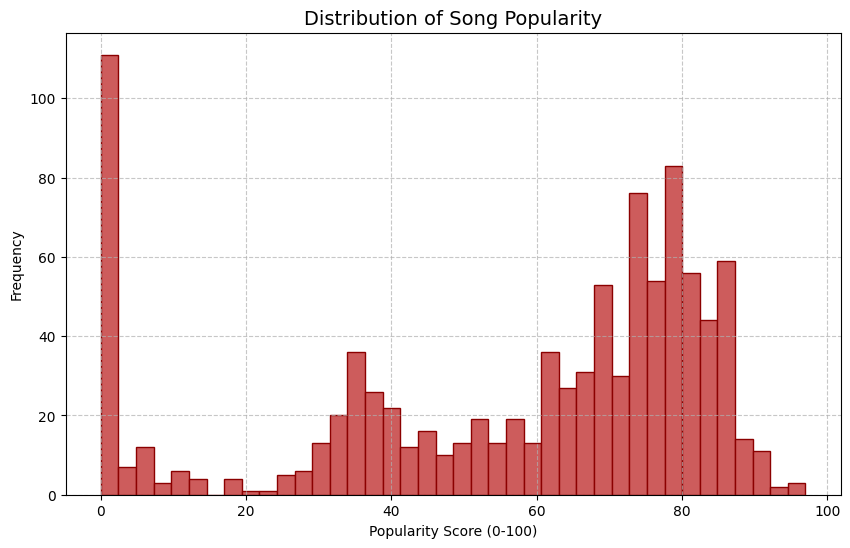

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=40, color='indianred',
edgecolor='darkred')
plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


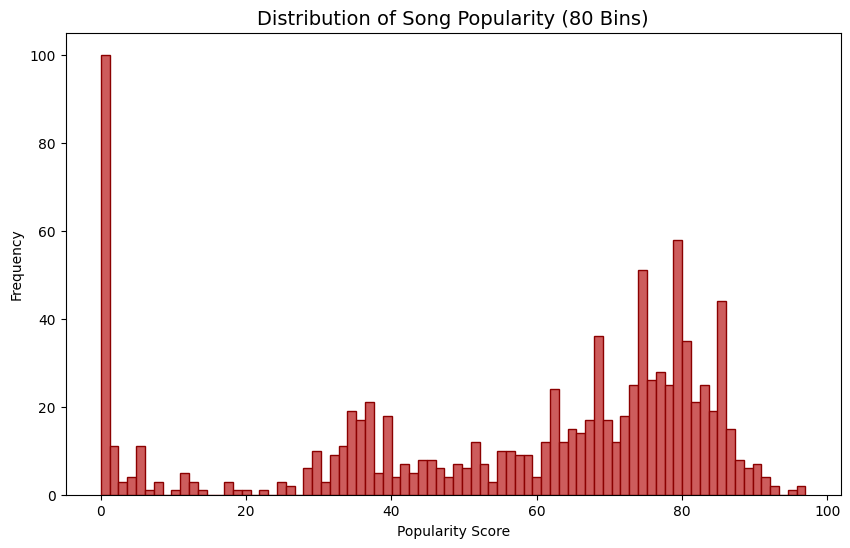

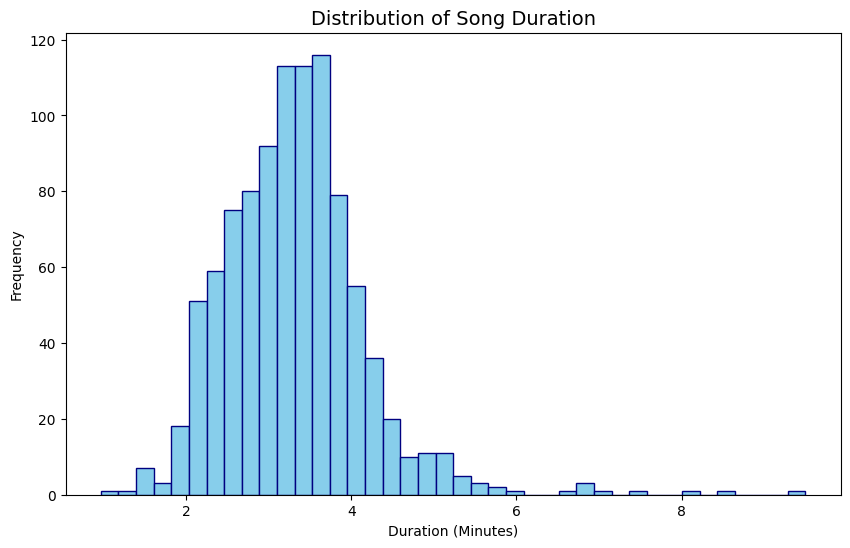

In [5]:
import matplotlib.pyplot as plt

# --- Try It: Change bins to 20, 50, or 80 ---
# This shows how "smooth" or "detailed" the data looks
plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=80, color='indianred', edgecolor='darkred')
plt.title('Distribution of Song Popularity (80 Bins)', fontsize=14)
plt.xlabel('Popularity Score')
plt.ylabel('Frequency')
plt.show()

# --- Try It: Compare with Song Duration ---
# Switching the data column to see a different metric
plt.figure(figsize=(10, 6))
plt.hist(df['duration_min'], bins=40, color='skyblue', edgecolor='navy') 
plt.title('Distribution of Song Duration', fontsize=14)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

# Boxplot - Duration Distribution by Top Artists 

C:\Users\kayer\AppData\Local\Temp\ipykernel_11628\2068409715.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data = df, palette='viridis')


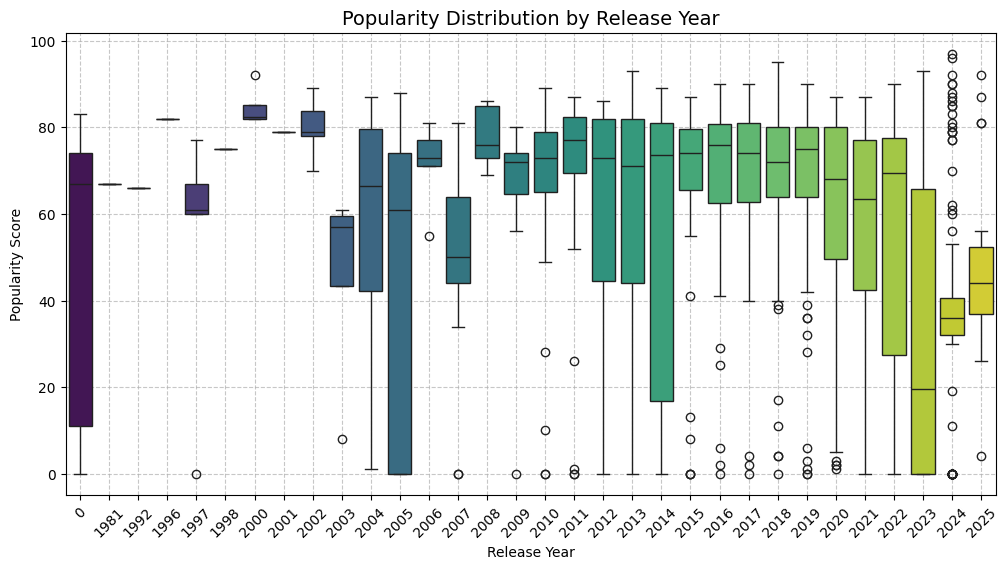

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data = df, palette='viridis')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation = 45)
plt.grid(True, linestyle='--', alpha = 0.7)
plt.show()

C:\Users\kayer\AppData\Local\Temp\ipykernel_11628\282145000.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='magma')


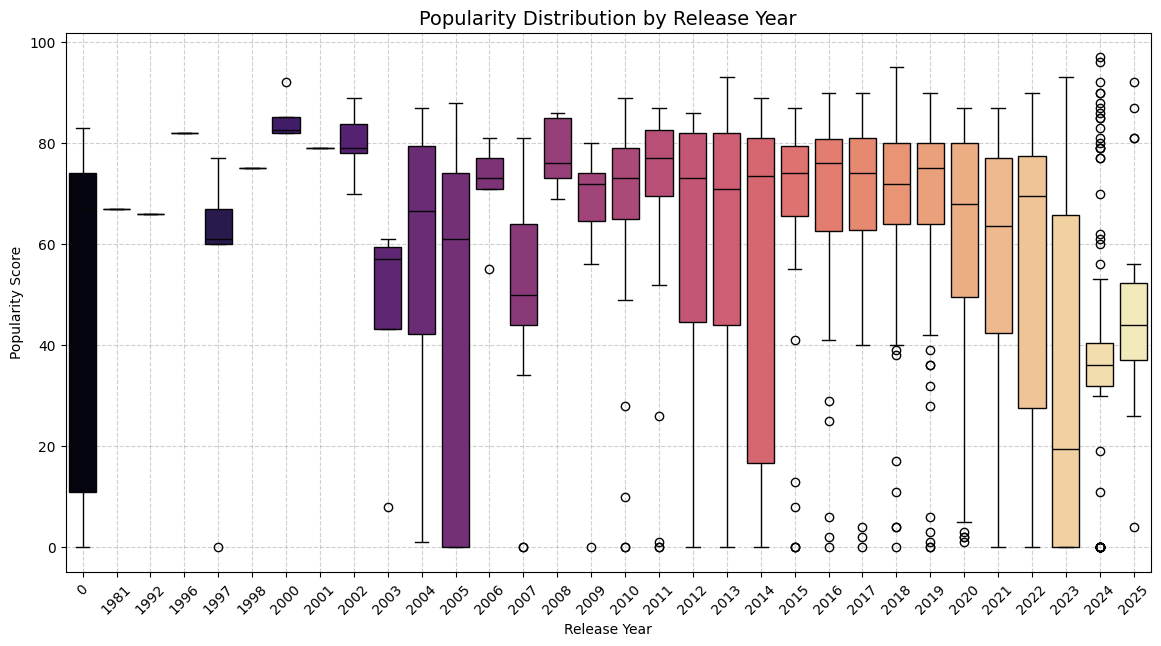

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the figure is large enough to see the years clearly
plt.figure(figsize=(14, 7))

# TRY IT: Modify palette to 'magma', 'plasma', or 'rocket'
sns.boxplot(x='year', y='popularity', data=df, palette='magma')

# Add labels and title
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')

# Rotate the year labels so they don't overlap
plt.xticks(rotation=45)

# Add a subtle grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Scatter Plot - Duration vs Popularity

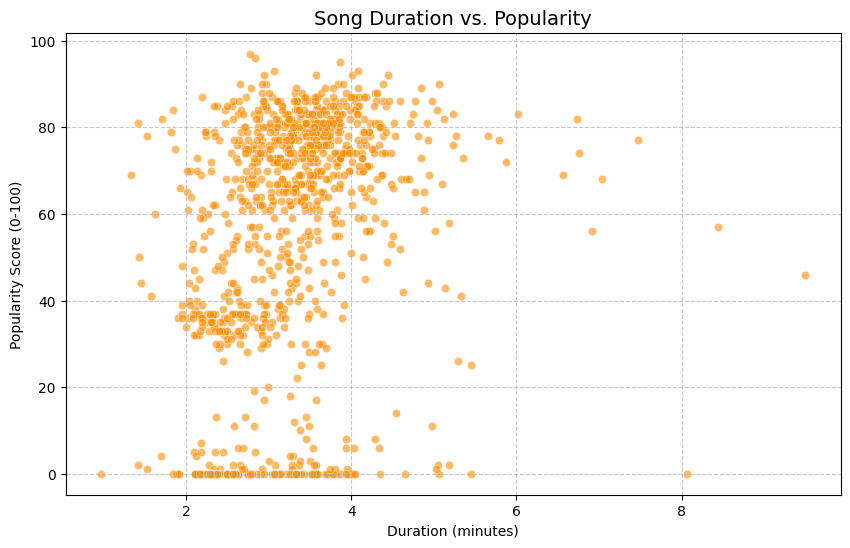

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min',
 y='popularity',
 data = df,
 color='darkorange',
 alpha = 0.6)
plt.title('Song Duration vs. Popularity', fontsize = 14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha = 0.7)
plt.show()

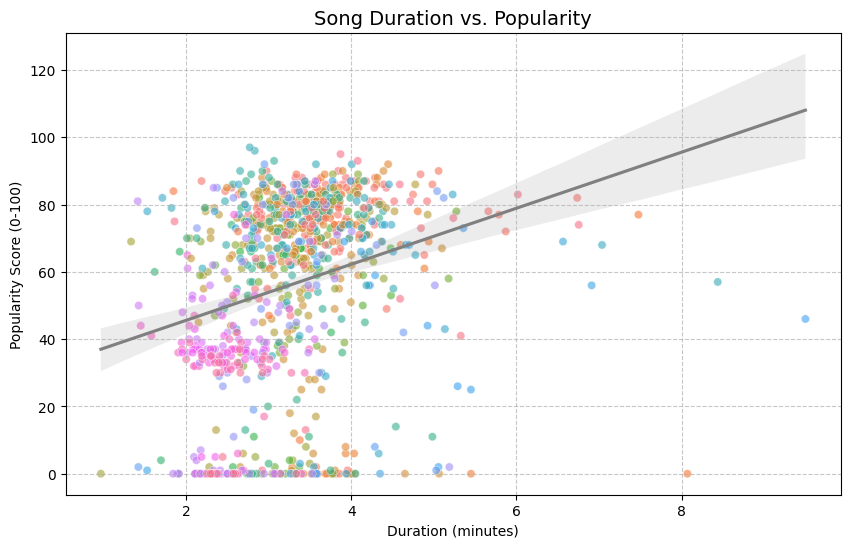

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# TRY IT: Using hue='artist' to color-code the points
# Note: If you have too many artists, this might look like a rainbow explosion!
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6, 
                hue='artist', legend=False) 

# TRY IT: Adding a regression line to see the overall trend
sns.regplot(x='duration_min', y='popularity', data=df, scatter=False, color='grey')

plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()


# Pair Plot - Feature Relationships Overview

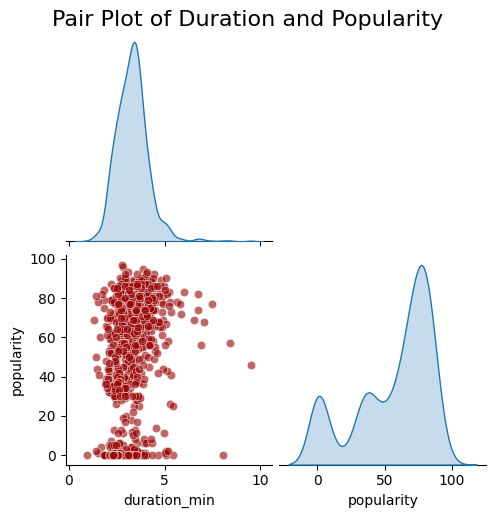

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using only the confirmed numerical columns: 'duration_min' and 'popularity'
key_features = ['duration_min', 'popularity']

# We use the simplified sns.pairplot function
sns.pairplot(
 df[key_features],
 diag_kind='kde',
 corner=True,
 plot_kws={'alpha': 0.6, 'color': '#990000'}
)
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize = 16)
plt.show()

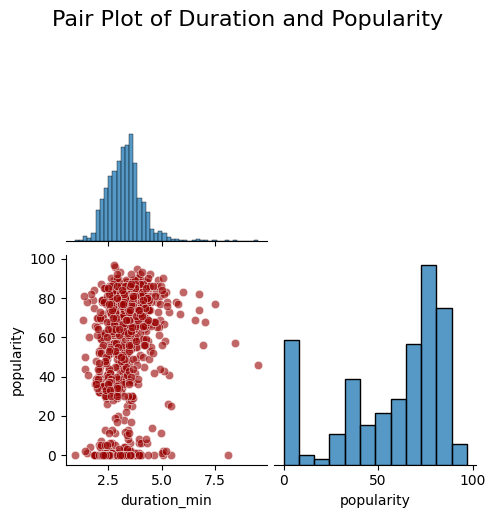

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the features are correct
key_features = ['duration_min', 'popularity']

# TRY IT: Change diag_kind from 'kde' (smooth) to 'hist' (bars)
sns.pairplot(
    df[key_features],
    diag_kind='hist',    # Changed this line as per your "Try It" instructions
    corner=True,         # This hides the redundant upper triangle of the grid
    plot_kws={'alpha': 0.6, 'color': '#990000'} # Customizes the scatter dots
)

# Move the title up a bit (y=1.02) so it doesn't overlap the plot
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)
plt.show()

# Joint Plot - Duration vs. Popularity Distribution

<Figure size 800x800 with 0 Axes>

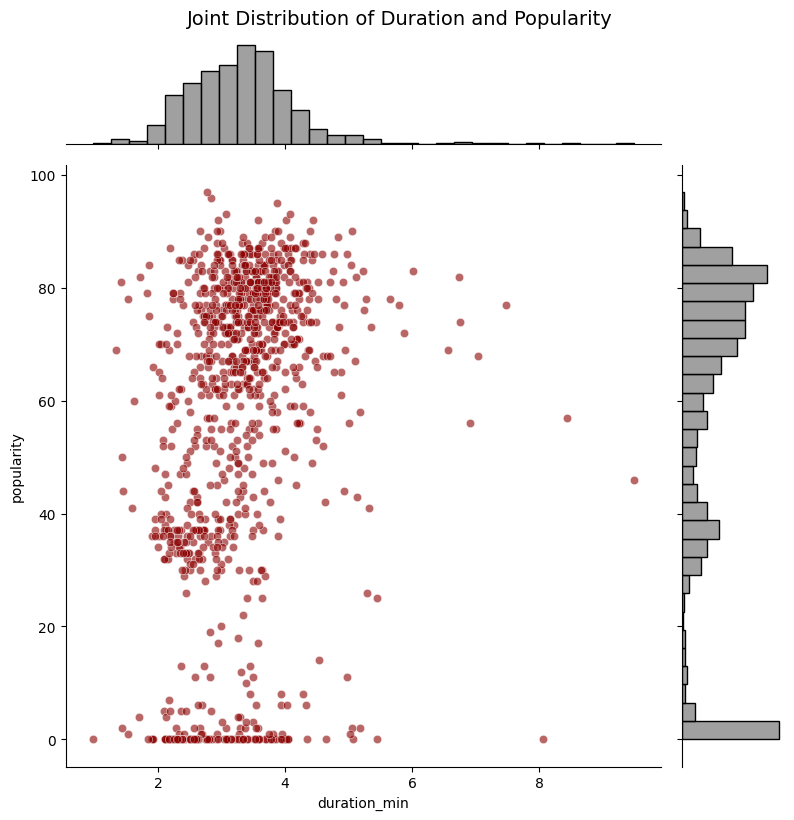

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns 
 
plt.figure(figsize=(8, 8)) 
sns.jointplot( 
    x='duration_min',  
    y='popularity',  
    data=df,  
    kind='scatter',  # Use 'scatter' for the central plot type 
    height=8,        # Controls the overall size of the plot 
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'}, 
    joint_kws={'alpha': 0.6, 'color': 'darkred'} 
) 
 
plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02, 
fontsize=14) 
plt.show() 

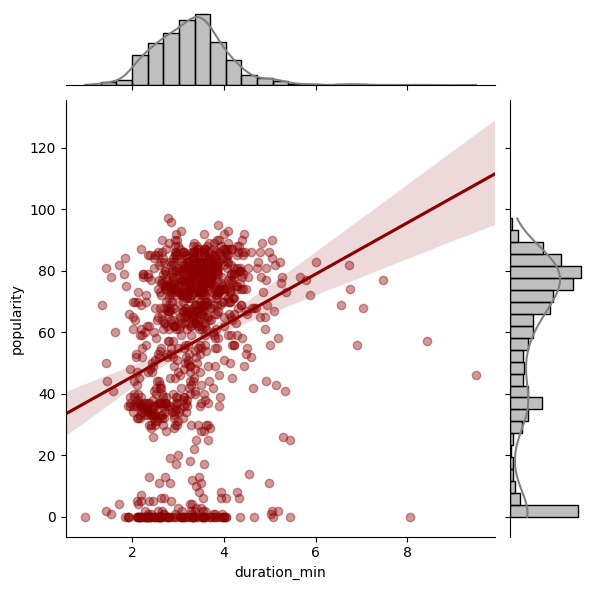

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we have the data and no missing values for these two columns
plot_data = df[['duration_min', 'popularity']].dropna()

# TRY IT: kind can be 'reg', 'scatter', 'kde', or 'hex'
sns.jointplot(
    x='duration_min', 
    y='popularity', 
    data=plot_data, 
    kind='reg',
    truncate=False, # This ensures the regression line covers the whole plot
    marginal_kws=dict(bins=25, color='gray', edgecolor='black'),
    joint_kws={'color': 'darkred', 'scatter_kws': {'alpha': 0.4}}
)

plt.show()

# Animated Line Chart – Evolution of Average Popularity Over Time

In [21]:
# Requirements:
# pip install matplotlib pillow pandas

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# Step 1: Load Dataset
dataset_path = "spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path)

# Step 2: Data Preparation
df ['release_date'] = pd.to_datetime(df ['release_date'], errors='coerce')
df['year'] = df ['release_date'].dt.year
df = df.dropna(subset=['year'])

# Compute average popularity per year
yearly_popularity = df.groupby('year') ['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')

# Step 3: Initialize the Figure
fig, ax = plt.subplots (figsize=(10,6))
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity ['popularity'].max() * 1.1)
line, = ax.plot([], [], color='royalblue', linewidth = 2.5, label='Average Popularity')
ax.set_title("Evolution of Track Popularity Over Time", fontsize = 14, color='navy')
ax.set_xlabel("Year of Release", fontsize = 12)
ax.set_ylabel("Average Popularity", fontsize = 12)
ax.legend(loc="upper left")
plt.tight_layout()

#--- Step 4: Define Animation Function
def animate(i):
 x = yearly_popularity['year'][:i]
 y = yearly_popularity['popularity'][:i]
 line.set_data(x, y)
 return line,

# Step 5: Create and Save Animation
ani = FuncAnimation (fig, animate, frames=len(yearly_popularity), interval = 100,
 repeat=False)

# Automatically Save the GIF
gif_path = os.path.abspath("yearly_popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f" GIF saved successfully at: {gif_path}")

# Step 6: Open the Saved GIF
webbrowser.open(f"file://{gif_path}") # Opens the saved GIF automatically
plt.close(fig)

 GIF saved successfully at: c:\Users\kayer\OneDrive\Desktop\COMPROGLAB_Rivera\ComProg_Lab7\yearly_popularity_trend.gif


In [15]:
# Try It: Change Animation Speed 
# Note: Reducing the interval (ms) makes the animation faster
ani = FuncAnimation(
    fig, 
    animate, 
    frames=len(yearly_popularity), 
    interval=60,
    repeat=False
)
# Re-save to see the speed difference
ani.save("yearly_popularity_fast.gif", writer=PillowWriter(fps=15))